<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/Copy_of_intro_to_embeddings_data_science_certification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings: A Hands-On Lab


The rule for this session: **you type, you run, you look at the number.** Every claim from the lecture gets tested here on things you already have intuitions about - movies, recipes, support tickets, song descriptions. If a result surprises you, that's the interesting part.

| § | You will learn
|---|------------------------------------------------------------
| 1 | A search engine that fails, so you know why we need embeddings
| 2 | Your first embedding — what `.encode()` actually returns  
| 3 | A working sentence similarity search over 40 movies            
| 4 | The vector space: clusters, odd-one-out, analogies         
| 5 | Similarity metrics, and a "how similar are these really?" playground
| 6 | Dimensions: the storage dial, and what breaks when you shrink it
| 7 | Three real applications: dedup, clustering, recommendation         
| 8 | Same thing in LangChain + FAISS                            

Runs on CPU. Colab-friendly.

---

## 0. Setup

Run this once.

In [ ]:
%pip install -q "sentence-transformers>=3.0" scikit-learn matplotlib rank_bm25

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=120)

print("ready")

ready


---

## 1. Break keyword search first

Before embeddings can impress you, ordinary keyword search has to disappoint you.
Here are 8 support tickets. We'll search them with BM25.

In [ ]:
tickets = [
    "My laptop won't turn on after the update.",
    "I forgot my password and can't sign in.",
    "The app crashes every time I open the camera.",
    "How do I get a refund for my subscription?",
    "My package arrived damaged.",
    "The website is really slow today.",
    "I want to cancel my membership.",
    "Can I change the email address on my account?",
]

for i, t in enumerate(tickets):
    print(i, t)

0 My laptop won't turn on after the update.
1 I forgot my password and can't sign in.
2 The app crashes every time I open the camera.
3 How do I get a refund for my subscription?
4 My package arrived damaged.
5 The website is really slow today.
6 I want to cancel my membership.
7 Can I change the email address on my account?


### What is BM25?

BM25 (Best Matching 25) is a ranking function used by search engines to estimate the relevance of documents to a given search query. It's a bag-of-words model that considers:

-   **Term frequency (TF):** How often a term appears in a document.
-   **Inverse document frequency (IDF):** How rare a term is across all documents (rarer terms are more important).
-   **Document length:** It penalizes longer documents to prevent them from being unfairly ranked higher just because they contain more words.

BM25 is a common choice for keyword search due to its effectiveness and efficiency.

In [ ]:
from rank_bm25 import BM25Okapi

In [ ]:
??BM25Okapi

In [ ]:
# Define a tokenization function to preprocess text by converting to lowercase, removing punctuation, and splitting into words.
tok = lambda s: s.lower().replace("?", "").replace(".", "").replace("'", " ").split()
# Initialize BM25Okapi with the tokenized support tickets.
bm25 = BM25Okapi([tok(t) for t in tickets])

# Define a function for keyword search using BM25.
def keyword_search(query):
    # Get BM25 scores for the query against the tokenized tickets.
    scores = bm25.get_scores(tok(query))
    print(f'query: "{query}"')
    # Print the top 3 most relevant tickets based on BM25 scores.
    for s, t in sorted(zip(scores, tickets), reverse=True)[:3]:
        print(f"{s:6.3f}    {t}")
    print()

keyword_search("my computer is dead")
keyword_search("I want my money back")
keyword_search("stop billing me")

query: "my computer is dead"
 1.780    The website is really slow today.
 0.454    My package arrived damaged.
 0.395    I want to cancel my membership.

query: "I want my money back"
 2.569    I want to cancel my membership.
 0.660    I forgot my password and can't sign in.
 0.660    How do I get a refund for my subscription?

query: "stop billing me"
 0.000    The website is really slow today.
 0.000    The app crashes every time I open the camera.
 0.000    My package arrived damaged.



### Look at what happened

Every score is **0.000**. Not "low" — *zero*. The right ticket is sitting there in the list and
keyword search cannot see it:

- "my computer is dead" ↔ "laptop won't turn on" — same meaning, zero shared words.
- "money back" ↔ "refund" — same meaning, zero shared words.
- "stop billing me" ↔ "cancel my membership" — same meaning, zero shared words.

This is the **vocabulary mismatch problem**, and it's not a tuning issue. BM25 counts word overlap.
When overlap is zero, there is no signal to rank on. Users don't phrase things the way your documents do, so this failure happens constantly and *silently* — the search returns something,
just not the right thing.

Hold onto these three queries.

### Why the problem is structural, not fixable

You might think: just add synonyms. But the deeper issue is how words are represented. Classic
sparse methods give each word its own slot - a "one-hot" vector.

In [ ]:
# Define a vocabulary for one-hot encoding.
VOCAB = ["laptop", "computer", "refund", "money", "cat", "kitten"]
# Create a dictionary to map words to their indices in the vocabulary.
idx = {w: i for i, w in enumerate(VOCAB)}

# Define a function to create a one-hot vector for a given word.
def one_hot(w):
    v = np.zeros(len(VOCAB))
    v[idx[w]] = 1.0
    return v

# Define a function to calculate the cosine similarity between two vectors.
def cosine(a, b):
    return float(a @ b / np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

# Calculate and print cosine similarity for pairs of related words using one-hot encoding.
print("laptop  vs computer :", one_hot("laptop"), "·", one_hot("computer"), "=", cosine(one_hot("laptop"), one_hot("computer")))
print("refund  vs money    :", cosine(one_hot("refund"), one_hot("money")))
print("cat     vs kitten   :", cosine(one_hot("cat"), one_hot("kitten")))

laptop  vs computer : [1. 0. 0. 0. 0. 0.] · [0. 1. 0. 0. 0. 0.] = 1e-12
refund  vs money    : 1e-12
cat     vs kitten   : 1e-12


### The issue with one-hot vectors

All zero, always. Two different one-hot vectors are *always* perpendicular - the 1s are never in
the same place. There is literally nowhere in this representation to store the fact that a laptop
is a computer.

**We need a representation where similar things are geometrically close.** That's an embedding.

---

## 2. Your first embedding

An embedding model is a function: text goes in, a list of numbers comes out.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")   # 22M params, downloads once

vec = model.encode("I love pizza")

print("type  :", type(vec))
print("shape :", vec.shape)
print("first 10 numbers:\n", vec[:10])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

type  : <class 'numpy.ndarray'>
shape : (384,)
first 10 numbers:
 [-0.099  0.034  0.01   0.053 -0.08   0.003  0.083  0.034  0.045 -0.066]


### What embeddings represent

That's it. `"I love pizza"` is now a point in 384-dimensional space.
The numbers themselves mean nothing to you — dimension 47 is not "food-ness." What matters is
**where this point sits relative to other points.**

In [ ]:
def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

anchor = model.encode("I love pizza")

for other in [
    "Pizza is my favourite food",
    "I really enjoy Italian cuisine",
    "I hate pizza",
    "The mitochondria is the powerhouse of the cell",
]:
    print(f"{cos(anchor, model.encode(other)):.3f}   {other}")

0.867   Pizza is my favourite food
0.603   I really enjoy Italian cuisine
0.806   I hate pizza
0.069   The mitochondria is the powerhouse of the cell


### Interpreting cosine similarity

Read that carefully — there's something worth arguing about:

- The paraphrase scores highest. Good.
- `"I hate pizza"` still scores **high**. Embeddings capture *topic* strongly and *sentiment*
  weakly. If you're building a system where "love" vs "hate" matters, cosine similarity alone will not save you. This trips people up constantly.
- The unrelated sentence scores near zero. Good.

**Try it yourself:** change the anchor and the candidates below. Find a pair that scores much
higher or lower than you expected.

In [ ]:
# ---- PLAYGROUND: edit these ----
anchor_text = "The concert last night was amazing"
candidates = [
    "The gig yesterday was fantastic",
    "I had a terrible time at the show",
    "My flight was delayed by three hours",
    "Live music is the best",
]
# --------------------------------

a = model.encode(anchor_text)
print(f'anchor: "{anchor_text}"\n')
for c in candidates:
    print(f"  {cos(a, model.encode(c)):.3f}   {c}")

anchor: "The concert last night was amazing"

  0.766   The gig yesterday was fantastic
  0.419   I had a terrible time at the show
  0.191   My flight was delayed by three hours
  0.424   Live music is the best


### Two things to read off the model card, always

In [ ]:
print("max input length :", model.max_seq_length, "tokens")
print("output dimensions:", model.get_sentence_embedding_dimension())

max input length : 256 tokens
output dimensions: 384


/tmp/ipykernel_494/2113388143.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("output dimensions:", model.get_sentence_embedding_dimension())


When using embedding models, always check these two parameters:

- **`max_seq_length` = 256 tokens.** Anything longer is **silently cut off**. No error, no warning.
  Feed it a 10-page PDF and you embed the first paragraph and throw the rest away.
- **384 dimensions**, fixed by the model. Feeding it a longer sentence does *not* give you a
  longer vector — see §6.

In [ ]:
# Proof that truncation is silent:
short = "The cat sat on the mat."
long  = short + " " + "This sentence is padding. " * 200
v1, v2 = model.encode(short), model.encode(long)

print("short text vector shape:", v1.shape)
print("long  text vector shape:", v2.shape, "  <- same, no warning, tail discarded")

short text vector shape: (384,)
long  text vector shape: (384,)   <- same, no warning, tail discarded


---

## 3. Sentence Similarity Search

In [ ]:
# Encode the entire list of support tickets into a matrix of embeddings. Normalize embeddings for cosine similarity to be a dot product.
ticket_vecs = model.encode(tickets, normalize_embeddings=True)
print("index shape:", ticket_vecs.shape)

# Define a function for semantic search.
def semantic_search(query, k=3):
    # Encode the query and normalize its embedding.
    a = model.encode(query, normalize_embeddings=True)

    # Calculate scores by taking the dot product of the query embedding with all ticket embeddings.
    scores = ticket_vecs @ a

    # Print the query and the top k most relevant tickets.
    print(f'query: "{query}"')
    for s, t in sorted(zip(scores, tickets), reverse=True)[:k]:
        print(f"{s:6.3f}    {t}")
    print()
    # Get the indices of the top k scores.
    top_indices = np.argsort(-scores)[:k]
    # Print the top k relevant tickets and their scores.
    for i in top_indices:
        print(f"{scores[i]:6.3f}    {tickets[i]}")
    print()

# Perform semantic searches for example queries.
semantic_search("my computer is dead")
semantic_search("I want my money back")
semantic_search("stop billing me")

index shape: (8, 384)
query: "my computer is dead"
    0.438  My laptop won't turn on after the update.
    0.340  I forgot my password and can't sign in.
    0.212  The website is really slow today.

query: "I want my money back"
    0.516  How do I get a refund for my subscription?
    0.447  I want to cancel my membership.
    0.288  I forgot my password and can't sign in.

query: "stop billing me"
    0.451  I want to cancel my membership.
    0.422  How do I get a refund for my subscription?
    0.220  Can I change the email address on my account?



All three now return the right ticket at rank 1. **Zero shared words in any case.** Nothing changed
except how the text is represented(using sentence embedding).


Notice also: the wrong answers aren't at 0.0 anymore — they're at 0.1–0.4. Dense scores are
*dense*; everything is a little bit similar to everything. So:

> **Rank, don't threshold.** "Above 0.7 = relevant" is not a rule that transfers between models,
> or even between datasets. If you need a threshold, measure it on your own data.

### Now a bigger, more fun index: 40 movies

In [ ]:
movies = [
    ("The Matrix", "A hacker discovers reality is a simulation and joins a rebellion against machines."),
    ("Inception", "A thief enters people's dreams to plant an idea in a target's mind."),
    ("Interstellar", "Astronauts travel through a wormhole to find a new home for humanity."),
    ("Blade Runner", "A detective hunts synthetic humans in a rain-soaked future city."),
    ("Arrival", "A linguist tries to communicate with alien visitors and perceives time differently."),
    ("Jurassic Park", "Scientists clone dinosaurs for a theme park that goes catastrophically wrong."),
    ("Jaws", "A small coastal town is terrorised by a giant great white shark."),
    ("Alien", "The crew of a spaceship is hunted by a deadly creature they brought aboard."),
    ("The Shining", "A writer slowly loses his mind while caretaking an isolated winter hotel."),
    ("Get Out", "A young man visits his girlfriend's family and uncovers a sinister secret."),
    ("Parasite", "A poor family schemes their way into working for a wealthy household."),
    ("The Godfather", "The aging patriarch of a crime dynasty hands control to his reluctant son."),
    ("Goodfellas", "A young man rises through the ranks of the mob and eventually turns informant."),
    ("Heat", "A career criminal and an obsessive detective circle each other in Los Angeles."),
    ("The Dark Knight", "A masked vigilante faces an anarchic criminal terrorising the city."),
    ("Spider-Man", "A teenager gains superpowers from a spider bite and learns responsibility."),
    ("Iron Man", "An arms manufacturer builds a powered suit and becomes a hero."),
    ("Mad Max: Fury Road", "Survivors flee a tyrant across a desert wasteland in armoured vehicles."),
    ("Die Hard", "An off-duty cop fights terrorists who seize a skyscraper at Christmas."),
    ("Mission: Impossible", "A spy is framed and must clear his name through elaborate heists."),
    ("Ocean's Eleven", "A crew of specialists plan an elaborate casino robbery."),
    ("Catch Me If You Can", "A teenage con artist forges cheques while an FBI agent pursues him."),
    ("The Social Network", "A student builds a social network and loses his friendships to it."),
    ("Moneyball", "A baseball manager uses statistics to assemble a competitive team on a budget."),
    ("Whiplash", "A young drummer is pushed to breaking point by an abusive music teacher."),
    ("La La Land", "An aspiring actress and a jazz musician fall in love in Los Angeles."),
    ("Amadeus", "A rival composer is consumed by jealousy of a prodigy's effortless genius."),
    ("Titanic", "Two passengers from different classes fall in love aboard a doomed ocean liner."),
    ("Notting Hill", "A bookshop owner unexpectedly falls for a world-famous actress."),
    ("Pride and Prejudice", "Two proud people slowly overcome misjudgement and fall in love."),
    ("Toy Story", "Toys come to life when humans leave and struggle with a new arrival."),
    ("Finding Nemo", "A clownfish crosses the ocean to rescue his captured son."),
    ("Up", "An elderly widower flies his house to South America with a stowaway scout."),
    ("Spirited Away", "A girl works in a bathhouse of spirits to rescue her transformed parents."),
    ("The Lion King", "A young lion prince flees after his father's death and later reclaims his throne."),
    ("Groundhog Day", "A cynical weatherman relives the same day over and over."),
    ("The Truman Show", "A man discovers his entire life is a televised reality programme."),
    ("Forrest Gump", "A kind-hearted man with a low IQ unwittingly witnesses decades of history."),
    ("The Shawshank Redemption", "A wrongly convicted banker endures prison and plans a long escape."),
    ("12 Angry Men", "A single juror pushes eleven others to reconsider a murder verdict."),
]
titles = [t for t, _ in movies]
plots  = [p for _, p in movies]
movie_vecs = model.encode(plots, normalize_embeddings=True, show_progress_bar=False)

print(movie_vecs.shape)

(40, 384)


In [ ]:
def find_movie(query, k=5):
    q = model.encode(query, normalize_embeddings=True)
    scores = movie_vecs @ q
    print(f'"{query}"')
    for i in np.argsort(-scores)[:k]:
        print(f"   {scores[i]:.3f}  {titles[i]:<26} {plots[i][:52]}...")
    print()

find_movie("something about robots and fake realities")
find_movie("a scary animal attacks people")
find_movie("a heist with a clever team")
find_movie("movies that made me cry about family")

"something about robots and fake realities"
   0.522  The Matrix                 A hacker discovers reality is a simulation and joins...
   0.320  The Truman Show            A man discovers his entire life is a televised reali...
   0.261  Inception                  A thief enters people's dreams to plant an idea in a...
   0.247  Iron Man                   An arms manufacturer builds a powered suit and becom...
   0.238  Toy Story                  Toys come to life when humans leave and struggle wit...

"a scary animal attacks people"
   0.426  Jaws                       A small coastal town is terrorised by a giant great ...
   0.407  Alien                      The crew of a spaceship is hunted by a deadly creatu...
   0.390  The Dark Knight            A masked vigilante faces an anarchic criminal terror...
   0.255  Die Hard                   An off-duty cop fights terrorists who seize a skyscr...
   0.246  Blade Runner               A detective hunts synthetic humans in a rain-soak

None of those queries share meaningful vocabulary with the plots they retrieve. "Scary animal
attacks people" finds *Jaws* and *Alien*. "Made me cry about family" finds... whatever it found —
look at it and decide whether you agree.

**Try it yourself:** Describe a movie you want to watch the way you'd say it to a friend. Vague is
fine — vague is the whole point.

In [ ]:
# ---- PLAYGROUND ----
find_movie("a film about obsession and being pushed too hard")
find_movie("cozy animated film for a rainy afternoon")
find_movie("")   # <- put your own query here

"a film about obsession and being pushed too hard"
   0.365  Pride and Prejudice        Two proud people slowly overcome misjudgement and fa...
   0.310  Heat                       A career criminal and an obsessive detective circle ...
   0.297  Get Out                    A young man visits his girlfriend's family and uncov...
   0.275  Titanic                    Two passengers from different classes fall in love a...
   0.273  Amadeus                    A rival composer is consumed by jealousy of a prodig...

"cozy animated film for a rainy afternoon"
   0.273  Groundhog Day              A cynical weatherman relives the same day over and o...
   0.269  Blade Runner               A detective hunts synthetic humans in a rain-soaked ...
   0.190  Die Hard                   An off-duty cop fights terrorists who seize a skyscr...
   0.178  Spirited Away              A girl works in a bathhouse of spirits to rescue her...
   0.172  Iron Man                   An arms manufacturer builds a p

**Discussion question for the room:** Find a query where this *fails* — where the top result is
clearly wrong. They're easy to find. Why did it fail? Usually one of:

1.  The query is about a *property* not in the plot text (release year, actor, rating).
2.  The query needs negation ("sci-fi but NOT space") - embeddings are bad at "not".

---

## 4. Look at the space

"Geometry = meaning" is the lecture's claim. Let's actually look.

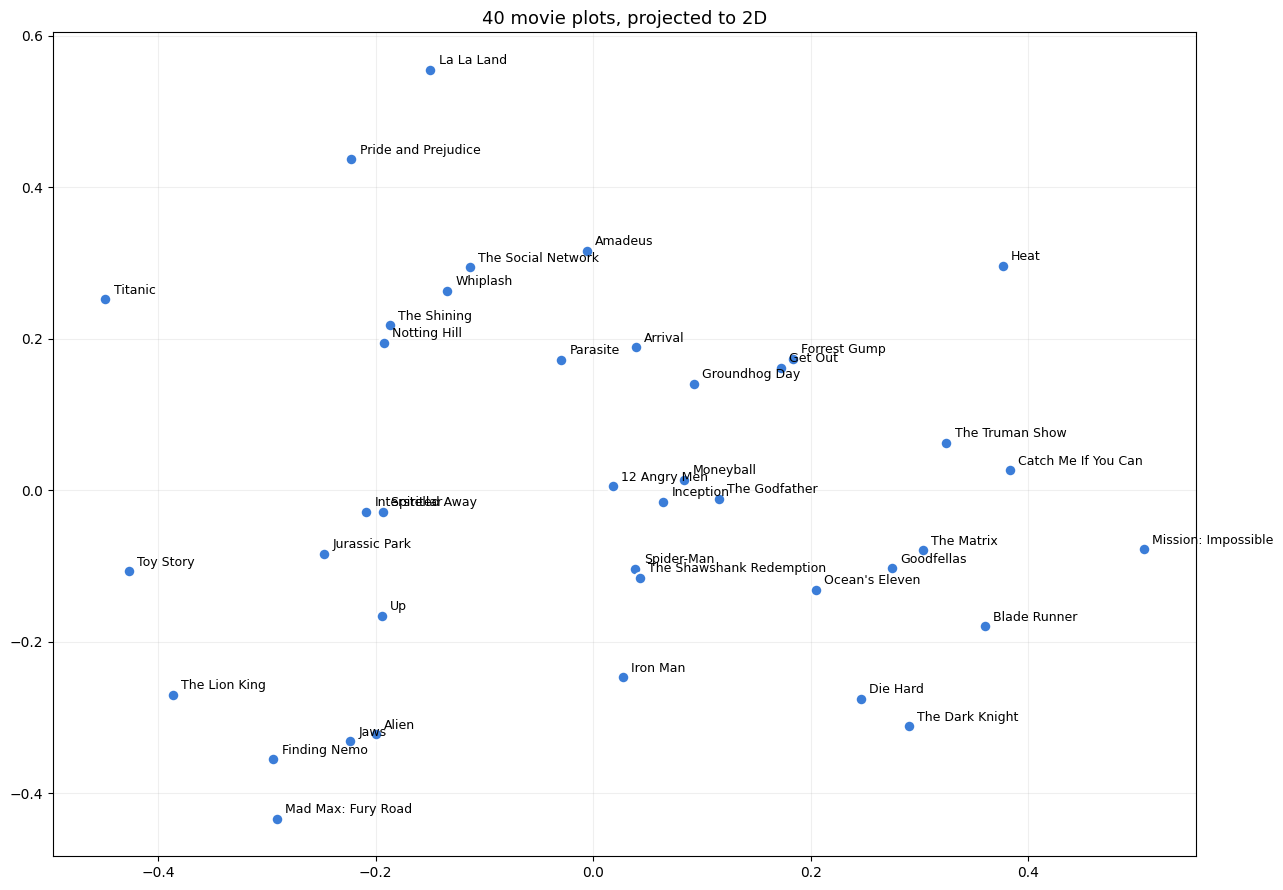

In [ ]:
from sklearn.decomposition import PCA

P = PCA(n_components=2, random_state=0).fit_transform(movie_vecs)

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(P[:, 0], P[:, 1], s=70, c="#3b7dd8", edgecolors="white", linewidths=1.5, zorder=3)
for i, t in enumerate(titles):
    ax.annotate(t, (P[i, 0], P[i, 1]), fontsize=9, xytext=(6, 4), textcoords="offset points")

ax.set_title("40 movie plots, projected to 2D", fontsize=13)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Caveats for 2D visualization

Nobody labelled these. No genre tags were used. Yet the sci-fi films drift together, the crime
films cluster, the animated films land near each other.

**A caveat you should say out loud:** this plot squashes 384 dimensions into 2. Most of the
information is gone. Two dots that look adjacent may not be close in the real space. *Always* check
the actual cosine before believing the picture.

### Odd one out

If meaning is geometry, then "which of these doesn't belong" is just "which point is furthest from
the average."

In [ ]:
# Define a function to find the 'odd one out' in a list of items based on their embeddings.
def odd_one_out(items):
    # Encode the items and normalize their embeddings.
    a = model.encode(items, normalize_embeddings=True)
    # Calculate the centroid (average vector) of the item embeddings.
    c = a.mean(axis=0)
    # Calculate the cosine similarity between each item and the centroid.
    cosines = a @ c / (np.linalg.norm(a, axis=1) * np.linalg.norm(c))
    # Normalize the centroid.
    c_norm = c / np.linalg.norm(c)
    # Calculate the similarity of each item to the centroid.
    sims = a @ c_norm / (np.linalg.norm(a, axis=1) * np.linalg.norm(c_norm))
    # Print items sorted by their similarity to the centroid, and identify the least similar item.
    print(f"odd one out: {items[np.argmin(sims)]}")

# Test the odd_one_out function with various sets of items.
odd_one_out(["apple", "banana", "orange", "grape", "hammer"])
odd_one_out(["football", "cricket", "tennis", "basketball", "poetry"])
odd_one_out(["Monday", "Tuesday", "Wednesday", "January", "Friday"])
odd_one_out(["happy", "joyful", "delighted", "cheerful", "furious"])

   0.577  hammer
   0.678  apple
   0.728  grape
   0.763  banana
   0.772  orange
   --> odd one out: hammer

   0.584  poetry
   0.783  tennis
   0.789  cricket
   0.813  football
   0.849  basketball
   --> odd one out: poetry

   0.616  January
   0.823  Friday
   0.902  Wednesday
   0.907  Monday
   0.935  Tuesday
   --> odd one out: January

   0.472  furious
   0.770  cheerful
   0.805  delighted
   0.819  happy
   0.834  joyful
   --> odd one out: furious



That last one is worth pausing on. `"furious"` is correctly flagged — but only barely, because all
five are emotion words and the model groups by *topic*. Same lesson as §2: embeddings are strong on
subject matter, weaker on polarity.

**Try your own set.** Try to build one that fools it.

In [ ]:
odd_one_out(["Paris", "London", "Tokyo", "Berlin", "Sandwich"])   # <- edit me

   0.561  Sandwich
   0.741  Tokyo
   0.787  London
   0.788  Paris
   0.825  Berlin
   --> odd one out: Sandwich



### Analogies: king − man + woman ≈ queen

The famous word2vec party trick. Vector arithmetic on meaning.

In [ ]:
# Define a bank of words for analogy tasks.
bank = ["king", "queen", "man", "woman", "boy", "girl", "prince", "princess",
        "France", "Paris", "Germany", "Berlin", "Japan", "Tokyo", "Italy", "Rome",
        "cat", "kitten", "dog", "puppy", "cow", "calf"]
# Encode the words in the bank and normalize their embeddings.
B = model.encode(bank, normalize_embeddings=True)
# Create a dictionary to map words to their indices in the bank.
bi = {w: i for i, w in enumerate(bank)}

# Define a function to perform vector analogy (a is to b as c is to ?).
def analogy(a, b, c, topn=3):
    # Calculate the analogy vector: vector(b) - vector(a) + vector(c).
    # Normalize the resulting vector.
    # Calculate similarity scores between the analogy vector and all words in the bank.
    # Exclude the input words from the results by setting their similarity to negative infinity.
    # Print the top 'topn' words closest to the analogy vector.
    for i in np.argsort(-sims)[:topn]:
        print(f"     {sims[i]:.3f}  {bank[i]}")
    print()

# Test the analogy function with various word pairs.
analogy("man", "king", "woman")
analogy("France", "Paris", "Germany")
analogy("cat", "kitten", "dog")

man : king :: woman : ?
     0.579  queen
     0.442  princess
     0.388  prince

France : Paris :: Germany : ?
     0.769  Berlin
     0.628  Tokyo
     0.496  Japan

cat : kitten :: dog : ?
     0.828  puppy
     0.395  cow
     0.387  girl



Results here are decent but noisier than the textbook version. That's expected and worth explaining: this is a *sentence* model, trained to make paraphrases similar — not a word2vec model
trained on the co-occurrence objective that makes analogies crisp. Different training objective, different geometry.

---

## 5. Similarity metrics

Three ways to measure "close". Do they disagree?

In [ ]:
a = model.encode("The movie was fantastic", normalize_embeddings=False)
b = model.encode("I really enjoyed the film", normalize_embeddings=False)

cosine_sim = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
dot        = a @ b
euclid     = np.linalg.norm(a - b)

print(f"cosine        : {cosine_sim:.4f}   (angle only, always in [-1, 1])")
print(f"dot product   : {dot:.4f}   (angle AND magnitude -> not comparable across texts)")
print(f"euclidean     : {euclid:.4f}   (straight-line distance, LOWER = closer)")

cosine        : 0.7608   (angle only, always in [-1, 1])
dot product   : 0.7608   (angle AND magnitude -> not comparable across texts)
euclidean     : 0.6917   (straight-line distance, LOWER = closer)


> **Practical takeaway:** set `normalize_embeddings=True` and stop worrying about metrics. Cosine,
> dot product, and Euclidean then rank identically, and dot product is the fastest.
>
> The one real mistake: using a metric your model wasn't trained for. Check the model card.

### The similarity matrix

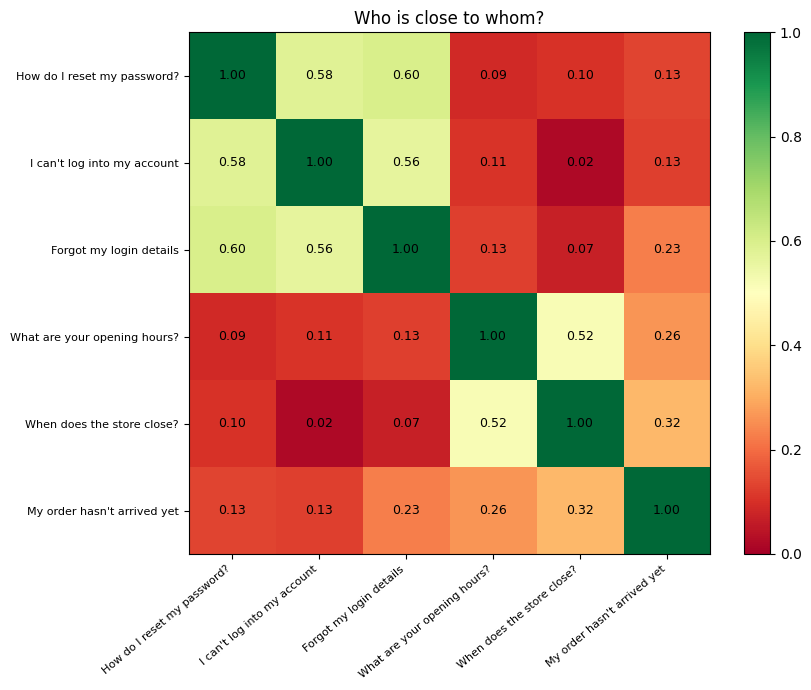

In [ ]:
probe = [
    "How do I reset my password?",
    "I can't log into my account",
    "Forgot my login details",
    "What are your opening hours?",
    "When does the store close?",
    "My order hasn't arrived yet",
]

E = model.encode(probe, normalize_embeddings=True)
S = E @ E.T

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(S, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(probe)))
ax.set_xticklabels(probe, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(probe)))
ax.set_yticklabels(probe, fontsize=8)

for i in range(len(probe)):
    for j in range(len(probe)):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Who is close to whom?")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

The block structure is visible without being told: three login questions form a warm square, two
opening-hours questions form another, and the delivery question sits alone.

---

## 6. Dimensions

Two beliefs to get rid of, both testable in one cell each.

**Belief 1: "longer text needs more dimensions."**

In [ ]:
for text in ["Hi.", "Hi there, how are you doing today?", "Hi. " * 100]:
    print(f"{len(text):>5} chars -> vector shape {model.encode(text).shape}")

    3 chars -> vector shape (384,)
   34 chars -> vector shape (384,)
  400 chars -> vector shape (384,)


### The effect of long text: dilution

Same shape every time. Dimensionality belongs to the **model**, not your input. But long text does hurt — just not that way. It **dilutes**. One vector is asked to summarise more
and more, until it represents nothing sharply. Watch it happen:

In [ ]:
query  = model.encode("What is the refund policy?", normalize_embeddings=True)
answer = "Refunds are issued within 14 days of purchase."
filler = ("The lobby is open from 9am. Staff parking is behind building C. "
          "The newsletter goes out on Thursdays. ")

print("chunk length | cosine(query, chunk)")
for k in [0, 1, 2, 4, 8, 16]:
    chunk = answer + " " + filler * k
    print(f"{len(chunk):>12} | {query @ model.encode(chunk, normalize_embeddings=True):.3f}")

chunk length | cosine(query, chunk)
          47 | 0.609
         149 | 0.501
         251 | 0.436
         455 | 0.401
         863 | 0.290
        1679 | 0.287


The answer sentence is in **every single chunk**. Its findability collapses anyway, purely from
being averaged with irrelevant text.

> This is the practical argument for **chunking**, and it's why "just use a long-context embedding
> model" doesn't solve the problem. A big chunk is a blurry chunk at any dimension count.

**Belief 2: "always pick the biggest dimension available."**

In [ ]:
def index_gb(n, d, bytes_per=4):
    return n * d * bytes_per / 1e9

print(f"{'vectors':>14} | {'384-d':>9} | {'768-d':>9} | {'1536-d':>9} | {'3072-d':>9}")
print("-" * 62)
for n in [10_000, 1_000_000, 100_000_000]:
    print(f"{n:>14,} | " + " | ".join(f"{index_gb(n,d):7.2f} GB" for d in [384, 768, 1536, 3072]))

       vectors |     384-d |     768-d |    1536-d |    3072-d
--------------------------------------------------------------
        10,000 |    0.02 GB |    0.03 GB |    0.06 GB |    0.12 GB
     1,000,000 |    1.54 GB |    3.07 GB |    6.14 GB |   12.29 GB
   100,000,000 |  153.60 GB |  307.20 GB |  614.40 GB | 1228.80 GB


### The cost of higher dimensions

At 100M vectors, going from 768-d to 3072-d costs about **900 GB of RAM** — and search gets slower
in proportion. That's a budget decision, not a free upgrade.

### Shrinking a vector: when it's fine, and when it destroys everything

**Matryoshka (MRL)** models are trained so the *first k dimensions are already a working
embedding* — you can slice them like a nesting doll. Models not trained that way have no such
property, and slicing them is vandalism. MiniLM is **not** MRL-trained, so let's watch it degrade.

In [ ]:
# Define a function to truncate vectors to a specified dimension and re-normalize them.
def truncate(vecs, dim):

# Define a set of test queries.
test_queries = ["a scary animal attacks people", "a heist with a clever team",
                "hackers and simulated reality", "an animated film about a lost child"]
# Encode the test queries and normalize their embeddings.
TQ = model.encode(test_queries, normalize_embeddings=True)

print(f"{'dims':>6} | top result for each test query")
print("-" * 78)
# Iterate through different reduced dimensions.
for d in [384, 256, 128, 64, 32, 16]:
    # Truncate both query and movie embeddings to the current dimension.
    tq, mv = truncate(TQ, d), truncate(movie_vecs, d)
    # Find the top movie title for each truncated query.
    tops = [titles[i] for i in np.argmax(tq @ mv.T, axis=1)]
    # Print the dimension and the top results, formatted.
    print(f"{d:>6} | " + ", ".join(f"{t[:17]:<17}" for t in tops))

  dims | top result for each test query
------------------------------------------------------------------------------
   384 | Jaws             , Mission: Impossib, The Matrix       , Toy Story        
   256 | Jaws             , Mission: Impossib, The Matrix       , Spirited Away    
   128 | Jaws             , Mission: Impossib, The Matrix       , Spirited Away    
    64 | Alien            , Mission: Impossib, The Matrix       , Mad Max: Fury Roa
    32 | Alien            , Mission: Impossib, The Matrix       , Finding Nemo     
    16 | Titanic          , Spider-Man       , The Matrix       , Get Out          


Read down the columns. The top rows agree; somewhere below, results start scrambling — and they
scramble *erratically*, not gracefully. That erratic-ness is the signature of truncating a model
that was never trained for it.

Two rules fall out:

1.  **Only truncate MRL-trained models** (`text-embedding-3-*`, Nomic, Gemini).
2.  **Always re-normalize after slicing** — the `truncate` function above does. Forgetting is a
    classic bug: your cosines quietly stop being cosines.

**Exercise:** re-run this with an MRL model and compare how gracefully it degrades:

```python
mrl = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)
```

---

## 7. Three Aplications

Search is the famous application. These three are just as common and take about ten lines each.

### 7a. Deduplication — finding near-identical text

In [ ]:
# Define a list of customer reviews, some of which are near-duplicates.
reviews = [
    "Great product, arrived quickly and works perfectly.",
    "Excellent item, fast delivery and functions great.",     # dup of 0
    "Terrible. Broke after two days.",
    "Awful quality, stopped working within 48 hours.",        # dup of 2
    "The colour is different from the photo.",
    "Shipping took three weeks, unacceptable.",
    "Delivery was extremely slow, took almost a month.",      # dup of 5
]

# Encode the reviews and normalize their embeddings.
# Calculate the similarity matrix.
# Set diagonal elements to 0 to avoid self-similarity.


# Define a similarity threshold for identifying near-duplicates.
THRESHOLD = 0.65
print(f"near-duplicate pairs (cosine > {THRESHOLD}):\n")
# Iterate through the upper triangle of the similarity matrix to find pairs above the threshold.
for i in range(len(reviews)):
    for j in range(i + 1, len(reviews)):
        if S[i, j] > THRESHOLD:
            # Print the similarity score and the two near-duplicate reviews.
            print(f"  {S[i,j]:.3f}\n     A: {reviews[i]}\n     B: {reviews[j]}\n")

near-duplicate pairs (cosine > 0.65):

  0.661
     A: Terrible. Broke after two days.
     B: Awful quality, stopped working within 48 hours.

  0.675
     A: Shipping took three weeks, unacceptable.
     B: Delivery was extremely slow, took almost a month.



**Note the threshold is hand-tuned.** Nudge `THRESHOLD` to 0.5 and 0.8 and see what changes.

### 7b. Clustering — discovering topics with no labels

In [ ]:
from sklearn.cluster import KMeans

feedback = [
    "The app crashes when I upload a photo.",
    "Login button does nothing on mobile.",
    "Getting a 500 error on checkout.",
    "The interface is beautiful and easy to use.",
    "Love the new dark mode.",
    "Really clean design, well done.",
    "Way too expensive for what it offers.",
    "The subscription price went up again.",
    "Not worth thirty dollars a month.",
    "Support never replied to my email.",
    "Waited four days for a response.",
    "Customer service was unhelpful and slow.",
]

F = model.encode(feedback, normalize_embeddings=True)
labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(F)

for c in range(4):
    print(f"--- cluster {c} ---")
    for t, l in zip(feedback, labels):
        if l == c:
            print("   ", t)
    print()

--- cluster 0 ---
    Login button does nothing on mobile.
    Support never replied to my email.
    Waited four days for a response.
    Customer service was unhelpful and slow.

--- cluster 1 ---
    The interface is beautiful and easy to use.
    Love the new dark mode.
    Really clean design, well done.

--- cluster 2 ---
    The app crashes when I upload a photo.
    Getting a 500 error on checkout.

--- cluster 3 ---
    Way too expensive for what it offers.
    The subscription price went up again.
    Not worth thirty dollars a month.



**Try:** change `n_clusters` to 2, then 6. Which grouping is "right"? There's no ground truth —
that's a genuine and often uncomfortable property of unsupervised methods.

### 7c. Recommendation — "more like this"

In [ ]:
def more_like(title, k=4):
    i = titles.index(title)
    scores = movie_vecs @ movie_vecs[i]
    scores[i] = -np.inf
    print(f"Because you watched {title}:")
    for j in np.argsort(-scores)[:k]:
        print(f"   {scores[j]:.3f}  {titles[j]}")
    print()

more_like("The Matrix")
more_like("Toy Story")
more_like("Ocean's Eleven")

Because you watched The Matrix:
   0.419  The Truman Show
   0.352  Inception
   0.334  Ocean's Eleven
   0.306  Iron Man

Because you watched Toy Story:
   0.330  Interstellar
   0.280  Inception
   0.277  The Lion King
   0.259  Jurassic Park

Because you watched Ocean's Eleven:
   0.386  The Shawshank Redemption
   0.334  The Matrix
   0.306  Inception
   0.294  Alien



That's a content-based recommender in six lines. It needs no user history at all — which means it
works on day one, before you have any users. (Netflix-style collaborative filtering needs the
opposite: lots of history, no content understanding. Real systems blend both.)

**Try it:** `more_like("Whiplash")`. Does the result make sense to you? Argue about it.

In [ ]:
more_like("Whiplash")   # <- swap in any title from `titles`

Because you watched Whiplash:
   0.304  Amadeus
   0.288  The Social Network
   0.209  Goodfellas
   0.200  Pride and Prejudice



---

## 7. The same thing in LangChain

Everything above used raw numpy so you could see the mechanics. In practice you'd use a library
that handles the index for you. The concepts map one-to-one.

In [ ]:
%pip install -q langchain-huggingface langchain-community faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"normalize_embeddings": True},
)

# Note the TWO methods - this is where the §8 prefix asymmetry lives.
print("embed_documents ->", np.array(embeddings.embed_documents(plots[:3])).shape)
print("embed_query     ->", len(embeddings.embed_query("space movies")))

/tmp/ipykernel_2039/1831434081.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embed_documents -> (3, 384)
embed_query     -> 384


In [ ]:
store = FAISS.from_texts(plots, embeddings, metadatas=[{"title": t} for t in titles])
for doc, score in store.similarity_search_with_score("a lonely person in a strange world", k=4):
    print(f"{score:.3f}  {doc.metadata['title']}")

1.220  Forrest Gump
1.237  The Social Network
1.272  The Shining
1.327  Groundhog Day


> **Careful with that score:** FAISS returns a **distance** here — *lower is better* — not a
> cosine similarity. Sorting it the wrong way is one of the most common beginner bugs in RAG.
> Check the direction before you build anything on top of it.

The retriever interface is what a RAG chain plugs into:

In [ ]:
retriever = store.as_retriever(search_kwargs={"k": 3})
for doc in retriever.invoke("films about growing up"):
    print("-", doc.metadata["title"])

- Spirited Away
- Toy Story
- Goodfellas
